# Credit Card Fraud Detection — Model Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)

## 1. Load Model and Test Data

In [2]:
rf = joblib.load('../models/model.pkl')
X_train, X_test, y_train, y_test, X_train_smote, y_train_smote = joblib.load('../data/processed_data.pkl')

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print(rf)

RandomForestClassifier(n_jobs=-1, random_state=42)


## 2. Confusion Matrix

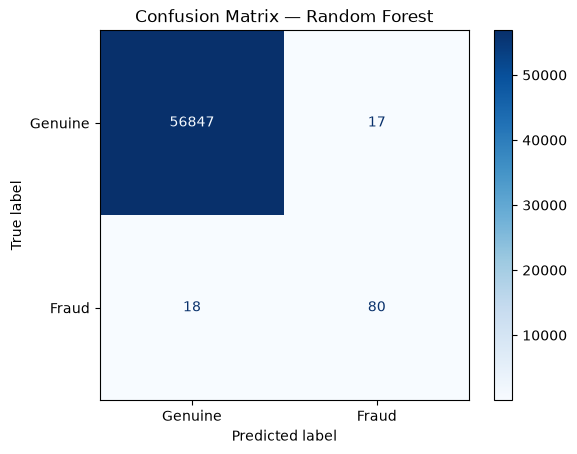

In [3]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Random Forest')
plt.show()

## 3. ROC Curve

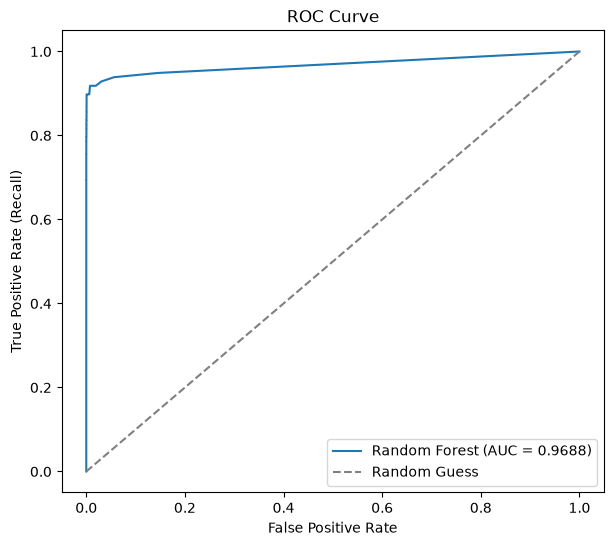

In [4]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 4. Precision-Recall Curve

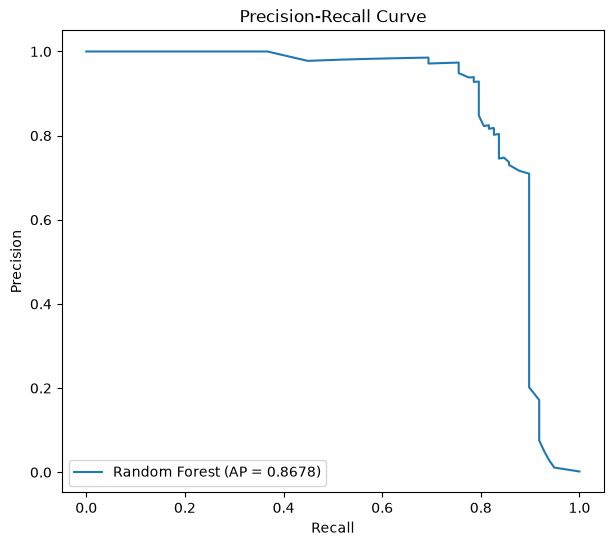

In [5]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f'Random Forest (AP = {avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 5. Summary

- **Model:** Random Forest (100 trees), trained on SMOTE-balanced data, evaluated on original imbalanced test set
- **Confusion Matrix:** 80/98 frauds correctly caught, 18 missed, 17 false alarms on genuine transactions
- **Precision (fraud):** 0.82 | **Recall (fraud):** 0.82 | **F1-score:** 0.82
- **ROC-AUC:** 0.9688 | **Average Precision (PR-AUC):** 0.8678
- The model performs well across a wide range of thresholds, with precision staying high (~1.0) up to recall ≈ 0.7, then dropping sharply past recall ≈ 0.85 — indicating a natural tradeoff point for deployment decisions.